#### TODO:
* split features into raw and t-series (impute as raw, and fillna -1 or 0 for t-series?)
* hypertuning
* add demographic parameters (and string params e.g. ett)
* check feature importance
* (add time series features - covariance? And feature interactions?)
* add feature selection using mlxtend SFS
* trial new sampling/training regime
* include non rfd patients
* improve class size balancing so that we retain all NRFD instances for patients who were declared fit for discharge but had a negative outcome - these are the harder cases, and they are currently being diluted by the other NRFD instances (from earlier in stays).

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
%matplotlib inline

In [2]:
FILLNA = False
FILLNA_VAL = 0

In [3]:
project_name = 'smartt_bmj_open_plus'

In [4]:
save_to_path = Path(f"E:/SMARTT/data/processed/{project_name}")

In [5]:
final_cohort = pd.read_json('..\data\processed\linked_cohort_181024.json', convert_dates=['admitStoreDateTime', 'dischargeStoreDateTime', 'rfd_datetime'])

In [6]:
all_samples = pd.read_csv(save_to_path / f"all_24hr_samples_final_cohort_.csv", low_memory=False)

In [7]:
all_high_freq_samples = pd.read_csv(save_to_path / f"all_4hr_samples_from_12_hours_final_cohort_.csv", low_memory=False)

In [8]:
original_features = [
    'Glasgow Coma Scale_ffill', 'temperature_ffill', 'arterial blood pressure (mean)_ffill', 'Fio2_ffill',
    'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'Heart rate_ffill', 'actual bicarbonate_ffill',
    'Hemoglobin_ffill', 'platelet count_ffill', 'Sodium_ffill', 'potassium_ffill',
    'creatinine_ffill', 'urea_ffill', 'Bilirubin_ffill', 'positive end-expiratory pressure_ffill',
    #'hours_since_admission'
]

In [9]:
new_features = [
    c
    for c in all_samples.columns
    if '_ffill' in c and c not in original_features and 'trach' not in c and 'delta' not in c
]

In [10]:
temporal_features = [
    c
    for c in all_samples.columns
    if 'delta' in c
]

In [11]:
all_features = original_features + new_features + temporal_features

In [12]:
all_samples['label'] = [s in ['True', '1', 1] for s in all_samples['label']]

In [13]:
for f in all_samples[original_features + ['hours_since_admission', 'eid'] + new_features + temporal_features]:
    all_samples[f] = pd.to_numeric(all_samples[f], errors='coerce')

In [14]:
 all_samples = all_samples[
     ['time', 'hours_since_admission', 'label', 'eid']
     + all_features
]
# ].dropna()

In [15]:
NNeigh = 5
imputer = KNNImputer(n_neighbors=NNeigh)

In [16]:
impute_features = original_features + new_features
all_samples.loc[:,impute_features] = imputer.fit_transform(all_samples[impute_features])

In [17]:
if FILLNA:
    all_samples.loc[:,temporal_features] = all_samples[temporal_features].fillna(FILLNA_VAL, inplace=False)

In [18]:
all_samples.groupby('label').count()

,time,hours_since_admission,eid,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,16796,16796,16796,16807,16807,16807,16807,16807,16807,16807,...,5935,16627,5946,5946,13644,5163,4829,14062,4055,4055
True,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129,...,1444,3598,1446,1446,2978,1215,1160,1787,650,650


In [19]:
scaler = StandardScaler()

In [20]:
scaled_samples = all_samples.copy()
# scaled_samples[original_features] = scaler.fit_transform(scaled_samples[original_features])
scaled_samples[all_features] = scaler.fit_transform(scaled_samples[all_features])

In [21]:
desired_class_size = len(scaled_samples[scaled_samples.label==1])

In [22]:
scaled_samples = pd.concat([
    scaled_samples[scaled_samples.label==1],
    scaled_samples[scaled_samples.label==0].sample(n=desired_class_size)
])

In [23]:
train, test = train_test_split(final_cohort[final_cohort['Declared clinically ready for discharge']=='Yes'], test_size=0.2)

In [24]:
# train, test = train_test_split(scaled_samples, test_size=0.2)
train = scaled_samples[scaled_samples.eid.isin(train.encounterId)]
test = scaled_samples[scaled_samples.eid.isin(test.encounterId)]

In [25]:
lr_features = original_features
rf_features = original_features
nrf_features = all_features

In [26]:
rf_grid_space ={
    'max_depth': [3, 5, 10, None],
    'n_estimators': [10, 100, 200],
    'max_features': [3, 5, 7, 'sqrt', None],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 5],
}

In [27]:
# clf = RandomForestClassifier(random_state=0).fit(
#     train[original_features],
#     train['label'],
# )
clf = GridSearchCV(RandomForestClassifier(), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[rf_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


In [28]:
clf.score(
    test[rf_features],
    test['label']
)

0.7696108709079679

In [29]:
# nclf = RandomForestClassifier(random_state=0).fit(
#     train[original_features + new_features],
#     train['label'],
# )
nclf = GridSearchCV(RandomForestClassifier(), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[nrf_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [30]:
nclf.score(
    test[nrf_features],
    test['label']
)

0.8035824583075973

In [31]:
lr_clf = LogisticRegression(random_state=0).fit(
    train[lr_features],
    train['label'],
)

In [32]:
lr_clf.score(
    test[lr_features],
    test['label']
)

0.7739345274861026

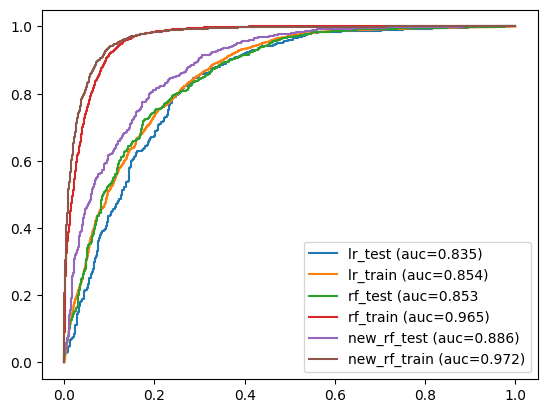

In [33]:
lr_features = original_features

fpr, tpr, thresholds = roc_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    lr_clf.predict_proba(train[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    lr_clf.predict_proba(train[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_train (auc={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_test (auc={auc:.3f}")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    clf.predict_proba(train[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    clf.predict_proba(train[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_train (auc={auc:.3f})")


## New RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    nclf.predict_proba(train[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    nclf.predict_proba(train[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_train (auc={auc:.3f})")


plt.legend();

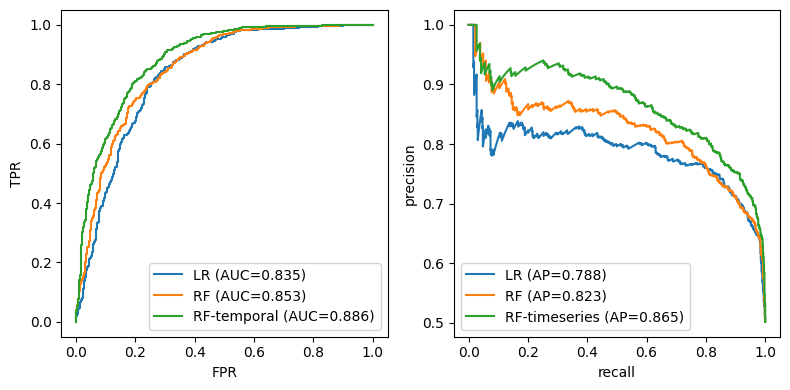

In [36]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
fpr, tpr, thresholds = roc_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"LR (AUC={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"RF (AUC={auc:.3f})")

## New RF:
# fpr, tpr, thresholds = roc_curve(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1],
#     pos_label=1
# )
# auc = roc_auc_score(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1]
# )
fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"RF-temporal (AUC={auc:.3f})")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend();
################# PRC
plt.subplot(1,2,2)
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(recall, precision, label=f"LR (AP={auc:.3f})")

## RF:
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(recall, precision, label=f"RF (AP={auc:.3f})")

## New RF:
# precision, recall, thresholds = precision_recall_curve(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1],
#     pos_label=1
# )
# auc = average_precision_score(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1]
# )
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1]
)
plt.plot(recall, precision, label=f"RF-timeseries (AP={auc:.3f})")
plt.xlabel('recall')
plt.ylabel('precision')
plt.legend();
plt.tight_layout()

In [37]:
len(all_features)

75

In [38]:
nclf.best_params_

{'max_depth': 10,
 'max_features': 3,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [39]:
rfc1 = RandomForestClassifier(**nclf.best_params_)
rfc2 = RandomForestClassifier(**nclf.best_params_)

In [40]:
sfs1 = SFS(
    estimator=rfc1,
    k_features=(10,55),
    forward=True, 
    floating=False,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

In [41]:
sfs1.fit(
    train[nrf_features],
    train['label'],
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 out of  75 | elapsed:   19.1s remaining:    6.4s
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed:   20.2s finished
Features: 1/55[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  54 out of  74 | elapsed:    9.8s remaining:    3.6s
[Parallel(n_jobs=-1)]: Done  74 out of  74 | elapsed:   11.0s finished
Features: 2/55[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 out of  73 | elapsed:   17.2s remaining:    6.9s
[Parallel(n_jobs=-1)]: Done  73 out of  73 | elapsed:   18.5s finished
Features: 3/55[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  72 | elapsed:   19.6s remaining:    8.6s
[Parallel(n_jobs=-1)]: Done  72 out of  72 | elapsed:   22.2s finished
Features: 4/55[Parallel(n_jobs=-1)]: Using

SequentialFeatureSelector(estimator=RandomForestClassifier(max_depth=10,
                                                           max_features=3,
                                                           min_samples_leaf=3,
                                                           n_estimators=200),
                          k_features=(10, 55), n_jobs=-1, scoring='accuracy',
                          verbose=1)

In [42]:
selected_features = [all_features[f] for f in sfs1.k_feature_idx_]
print(selected_features)
len(selected_features)

['Glasgow Coma Scale_ffill', 'temperature_ffill', 'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'Heart rate_ffill', 'Hemoglobin_ffill', 'Sodium_ffill', 'potassium_ffill', 'creatinine_ffill', 'urea_ffill', 'Pao2_ffill', 'C-reactive protein_ffill', 'arterial blood pressure (systolic)_ffill', 'Richmond Agitation-Sedation Scale_ffill', 'Glasgow Coma Scale_ffill_delta_1', 'temperature_ffill_delta_1', 'arterial blood pressure (mean)_ffill_delta_1', 'Fio2_ffill_delta_1', 'Fio2_ffill_delta_3', 'respiratory rate_ffill_delta_2', 'actual bicarbonate_ffill_delta_1', 'Hemoglobin_ffill_delta_1', 'Hemoglobin_ffill_delta_3', 'platelet count_ffill_delta_1', 'platelet count_ffill_delta_3', 'Sodium_ffill_delta_1', 'potassium_ffill_delta_1', 'creatinine_ffill_delta_1', 'creatinine_ffill_delta_2', 'creatinine_ffill_delta_3', 'urea_ffill_delta_2', 'urea_ffill_delta_3', 'Bilirubin_ffill_delta_3', 'positive end-expiratory pressure_ffill_delta_1', 'positive end-expiratory pressure_ffill_delta_2

35

In [43]:
sfs1.k_score_

np.float64(0.8224317744021963)

In [44]:
sfs1.get_metric_dict()

{1: {'feature_idx': (0,),
  'cv_scores': array([0.74755823, 0.73308271, 0.73759398, 0.73609023, 0.70526316]),
  'avg_score': np.float64(0.731917660417008),
  'feature_names': ('Glasgow Coma Scale_ffill',),
  'ci_bound': np.float64(0.018231915030079815),
  'std_dev': np.float64(0.014185049296877753),
  'std_err': np.float64(0.0070925246484388775)},
 2: {'feature_idx': (0, 54),
  'cv_scores': array([0.76183321, 0.73759398, 0.75714286, 0.77293233, 0.72255639]),
  'avg_score': np.float64(0.750411754404795),
  'feature_names': ('Glasgow Coma Scale_ffill',
   'platelet count_ffill_delta_1'),
  'ci_bound': np.float64(0.023157719589868734),
  'std_dev': np.float64(0.018017492591622816),
  'std_err': np.float64(0.009008746295811408)},
 3: {'feature_idx': (0, 12, 54),
  'cv_scores': array([0.78136739, 0.75864662, 0.77744361, 0.78045113, 0.72030075]),
  'avg_score': np.float64(0.7636418996401597),
  'feature_names': ('Glasgow Coma Scale_ffill',
   'creatinine_ffill',
   'platelet count_ffill_delt

In [45]:
# nclf = RandomForestClassifier(random_state=0).fit(
#     train[original_features + new_features],
#     train['label'],
# )
rfc2 = GridSearchCV(RandomForestClassifier(), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[selected_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [46]:
rfc2.score(
    test[selected_features],
    test['label']
)

0.810994441012971

### We now look at the performance on the 4-hourly sampled data:

In [47]:
all_high_freq_samples

,Unnamed: 0.1,Unnamed: 0,time,hours_since_admission,Pao2,actual bicarbonate,arterial oxygen saturation,Hemoglobin,platelet count,Sodium,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
0,12,12,2015-04-22 15:00:00,12.0,17.4,17.1,99.1,NaN,NaN,141.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,16,16,2015-04-22 19:00:00,16.0,9.4,16.8,92.0,NaN,NaN,142.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,20,20,2015-04-22 23:00:00,20.0,22.9,16.4,98.9,112.0,364.0,141.0,...,46.0,4.5,4.5,4.5,4.0,4.0,4.0,NaN,NaN,NaN
3,24,24,2015-04-23 03:00:00,24.0,16.4,16.7,98.8,NaN,NaN,142.0,...,46.0,4.5,4.5,4.5,4.0,4.0,4.0,NaN,NaN,NaN
4,28,28,2015-04-23 07:00:00,28.0,17.2,16.3,99.2,NaN,NaN,141.0,...,14.0,-1.7,4.5,-1.7,8.0,4.0,8.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276762,100,100,2023-02-12 17:00:00,100.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.9,NaN,NaN,3.0,NaN,NaN,0.0,NaN,NaN
276763,104,104,2023-02-12 21:00:00,104.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.2,NaN,NaN,2.0,NaN,NaN,0.0,NaN,NaN
276764,108,108,2023-02-13 01:00:00,108.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6.3,NaN,NaN,-1.0,NaN,NaN,0.0,NaN,NaN
276765,112,112,2023-02-13 05:00:00,112.0,12.2,22.9,97.3,82.0,142.0,138.0,...,NaN,11.1,NaN,NaN,-3.0,NaN,NaN,0.0,NaN,NaN


In [48]:
all_high_freq_samples['label'] = [s in ['True', '1', 1] for s in all_high_freq_samples['label']]

In [49]:
for f in all_high_freq_samples[original_features + ['hours_since_admission', 'eid'] + new_features + temporal_features]:
    all_high_freq_samples[f] = pd.to_numeric(all_high_freq_samples[f], errors='coerce')

In [50]:
 all_high_freq_samples = all_high_freq_samples[
     ['time', 'hours_since_admission', 'label', 'eid']
     + all_features
]
# ].dropna()

In [51]:
impute_features = original_features + new_features
all_high_freq_samples.loc[:,impute_features] = imputer.transform(all_high_freq_samples[impute_features])

In [52]:
if FILLNA:
    all_high_freq_samples.loc[:,temporal_features] = all_high_freq_samples[temporal_features].fillna(FILLNA_VAL, inplace=False)

In [53]:
all_high_freq_samples.groupby('label').count()

,time,hours_since_admission,eid,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,249941,249941,249941,249941,249941,249941,249941,249941,249941,249941,...,87482,228733,87619,87619,192880,75245,71341,185595,61677,61677
True,26826,26826,26826,26826,26826,26826,26826,26826,26826,26826,...,9120,25696,9115,9115,21471,7753,7302,12818,4055,4055


In [54]:
scaled_high_freq_samples = all_high_freq_samples.copy()
# scaled_samples[original_features] = scaler.fit_transform(scaled_samples[original_features])
scaled_high_freq_samples[all_features] = scaler.transform(scaled_high_freq_samples[all_features])

In [55]:
hf_test = scaled_high_freq_samples[scaled_high_freq_samples.eid.isin(test.eid.unique())]

#### Example IDs:
* 20749: u-shaped, rfd +ve outcome
* 19439: u-shaped, rfd +ve outcome
* 14749: clear drop, nrfd -ve outcome

In [56]:
_eid = hf_test.eid.sample(n=1).iloc[0]
example_encounter = hf_test[hf_test.eid==_eid]
print(_eid)

33620


In [57]:
def get_example_ecounter(group='A'):
    """
    Groups :
    A: RFD, +ve outcome
    B: RFD, -ve outcome
    C: NRFD, +ve outcome
    D: NRFD, _ve outcome
    """
    _eid = None
    example_encounter = []
    if group == 'A':
            _eid = hf_test[
                hf_test.eid.isin(final_cohort[(~final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==1)].encounterId)
            ].eid.sample(n=1).iloc[0]
            example_encounter = hf_test[hf_test.eid==_eid]
    elif group == 'B':
            _eid = hf_test[
                hf_test.eid.isin(final_cohort[(~final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==0)].encounterId)
            ].eid.sample(n=1).iloc[0]
            example_encounter = hf_test[hf_test.eid==_eid]
    elif group == 'C':
        _eid = final_cohort[(final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==1)].encounterId.sample(n=1).iloc[0]
        example_encounter = scaled_high_freq_samples[scaled_high_freq_samples.eid==_eid]
    elif group == 'D':
        _eid = final_cohort[(final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==0)].encounterId.sample(n=1).iloc[0]
        example_encounter = scaled_high_freq_samples[scaled_high_freq_samples.eid==_eid]
    
    # print(_eid, len(example_encounter))
    return _eid, example_encounter

In [58]:
_eid = final_cohort[(final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==0)].encounterId.sample(n=1).iloc[0]
example_encounter = scaled_high_freq_samples[scaled_high_freq_samples.eid==_eid]
print(_eid, len(example_encounter))

17875 0


In [59]:
final_cohort[final_cohort.encounterId==_eid][['Declared clinically ready for discharge', 'rfd_datetime', 'outcome', 'in_hospital_mortality', 'readmission',
       'readmission_this_stay']]

,Declared clinically ready for discharge,rfd_datetime,outcome,in_hospital_mortality,readmission,readmission_this_stay
4569,None,NaT,0,1,0,0


In [60]:
rfd_datetime_hours = (final_cohort[final_cohort.encounterId==_eid].iloc[0].rfd_datetime - final_cohort[final_cohort.encounterId==_eid].iloc[0].admitStoreDateTime).total_seconds() / 60**2

In [61]:
rfd_datetime_hours

nan

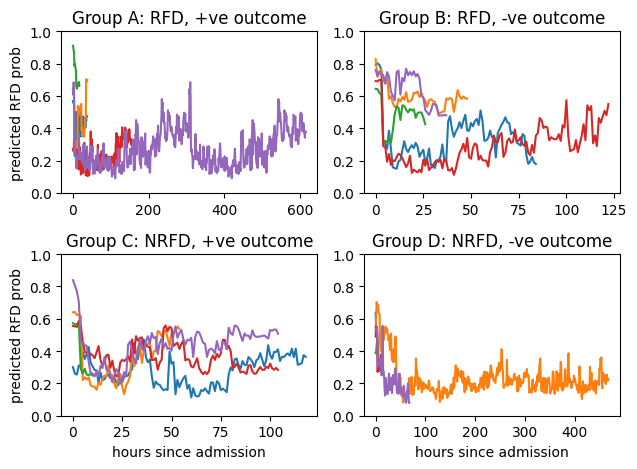

In [63]:
n_rep = 5
groups = {
    'A': 'RFD, +ve outcome', 
    'B': 'RFD, -ve outcome', 
    'C': 'NRFD, +ve outcome',
    'D': 'NRFD, -ve outcome'
}

for gi, g in enumerate(groups.keys()):
    plt.subplot(2,2,gi+1)
    plt.title(f"Group {g}: {groups[g]}")
    
    for r in range(n_rep):
        example_encounter=[]
        while len(example_encounter)==0:
            _eid, example_encounter = get_example_ecounter(g)
        example_predictions = nclf.predict_proba(example_encounter[nrf_features])[:,1]

        plt.plot(
            # scaler.inverse_transform(example_encounter[all_features])[:,all_features.index('hours_since_admission')],
            range(len(example_predictions)),
            example_predictions
        )
    plt.ylim([0,1])
    if gi >1:
        plt.xlabel('hours since admission')
    if gi in [0,2]:
        plt.ylabel('predicted RFD prob')
plt.tight_layout()

In [ ]:
example_predictions = nclf.predict_proba(example_encounter[nrf_features])[:,1]

In [ ]:
plt.plot(
    scaler.inverse_transform(example_encounter[all_features])[:,all_features.index('hours_since_admission')],
    example_predictions
)
# plt.axvline(rfd_datetime_hours, color='green')

In [ ]:
final_cohort.columns

#### This is like the example given in the documentation, but seems wrong to me and is very slow!:

In [ ]:
pipe = Pipeline([
    ('sfs', sfs1),
    ('rf', rfc2)
])

In [ ]:
param_grid ={
    'sfs__k_features': [10, 15, 20, 25, 30, 35],
    'sfs__estimator__max_depth': [3, 5, 10, None],
    'sfs__estimator__n_estimators': [10, 100, 200],
    'sfs__estimator__max_features': [3, 5, 7, 'sqrt', None],
    'sfs__estimator__min_samples_leaf': [1, 2, 3],
    'sfs__estimator__min_samples_split': [2, 3, 5],
    'rf__max_depth': [3, 5, 10, None],
    'rf__n_estimators': [10, 100, 200, 500],
    'rf__max_features': [3, 5, 7, 'sqrt', None],
    'rf__min_samples_leaf': [1, 2, 3],
    'rf__min_samples_split': [2, 3, 5],
}

In [ ]:
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

In [ ]:
gs.fit(
    train[original_features + new_features],
    train['label'],
)

In [ ]:
gs.get_params()

In [ ]:
lr_features = all_features

fpr, tpr, thresholds = roc_curve(
    test['label'],
    gs.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    gs.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    gs.predict_proba(train[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    gs.predict_proba(train[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_train (auc={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[original_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[original_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_test (auc={auc:.3f}")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    clf.predict_proba(train[original_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    clf.predict_proba(train[original_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_train (auc={auc:.3f})")


## New RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[original_features + new_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[original_features + new_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    nclf.predict_proba(train[original_features + new_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    nclf.predict_proba(train[original_features + new_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_train (auc={auc:.3f})")


plt.legend();


#### We now test the classifiers on the cohort subset that were not declared RFD.

There are two groups:
* those with positive outcomes, who are assigned label 1 at the end of their stay, but who may have been ready earlier,
* those with negative outcomes, who are assigned label 0 throughout. Adn we therefore hope for a low false positive rate (although they are not reflected in training).

We should also look at the NRFD instances for patients who were declared fit for discharge but had a negative outcoem - these should be harder cases for the classifier.